In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
from torch import nn
import matplotlib.pyplot as plt
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader, Subset
from torchinfo import summary

In [2]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

In [3]:
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32,padding=4),
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],std=[0.2470, 0.2435, 0.2616])
])

In [4]:
test_tf = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2470, 0.2435, 0.2616])
])

In [5]:
train_data = datasets.CIFAR10(
    root = "data",
    train = True,
    download = True,
    transform = train_tf,
    target_transform = None
)

In [6]:
test_data = datasets.CIFAR10(
    root = "data",
    train = False,
    download = True,
    transform = test_tf,
    target_transform = None
)

In [7]:
len(train_data)

50000

In [8]:
train_data[0]

(tensor([[[-1.9895e+00, -1.9895e+00, -1.9895e+00,  ..., -1.9895e+00,
           -1.9895e+00, -1.9895e+00],
          [-1.9895e+00, -1.9895e+00, -1.9895e+00,  ..., -1.9895e+00,
           -1.9895e+00, -1.9895e+00],
          [-1.9895e+00, -1.9895e+00, -1.9895e+00,  ..., -1.9895e+00,
           -1.9895e+00, -1.9895e+00],
          ...,
          [ 7.5721e-01,  7.5721e-01,  7.5721e-01,  ..., -1.9895e+00,
           -1.9895e+00, -1.9895e+00],
          [ 7.5721e-01,  7.5721e-01,  7.5721e-01,  ..., -1.9895e+00,
           -1.9895e+00, -1.9895e+00],
          [ 7.5721e-01,  7.5721e-01,  7.5721e-01,  ..., -1.9895e+00,
           -1.9895e+00, -1.9895e+00]],
 
         [[-1.9803e+00, -1.9803e+00, -1.9803e+00,  ..., -1.9803e+00,
           -1.9803e+00, -1.9803e+00],
          [-1.9803e+00, -1.9803e+00, -1.9803e+00,  ..., -1.9803e+00,
           -1.9803e+00, -1.9803e+00],
          [-1.9803e+00, -1.9803e+00, -1.9803e+00,  ..., -1.9803e+00,
           -1.9803e+00, -1.9803e+00],
          ...,
    

In [9]:
image , label = train_data[0]

In [10]:
class_names = train_data.classes

In [11]:
class_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [12]:
class_names[label]

'frog'

In [13]:
image.shape

torch.Size([3, 224, 224])

In [14]:
image = image.permute(1,2,0)

In [15]:
image.shape

torch.Size([224, 224, 3])

In [16]:
BATCH_SIZE = 32 
train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

In [17]:
class DepthWiseSeperableBlock(nn.Module):
    def __init__(self, in_features : int, out_features : int, stride: int):
        super().__init__()

        self.module = nn.Sequential(
            nn.Conv2d(in_channels=in_features,out_channels=in_features,kernel_size=3,stride=stride,padding=1,groups=in_features, bias=False),
            nn.BatchNorm2d(in_features),
            nn.ReLU(),
            nn.Conv2d(in_channels=in_features,out_channels=out_features,kernel_size=1,stride=1,padding=0,bias=False),
            nn.BatchNorm2d(out_features),
            nn.ReLU()
        )

    def forward(self,x):
        return self.module(x)

In [18]:
class MobileNetV1(nn.Module):
    def __init__(self, num_classes : int):
        super().__init__()

        #first conv2d layer
        self.first_conv_layer = nn.Sequential(
            nn.Conv2d(in_channels=3,out_channels=32,kernel_size=3,stride=2,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU()
        )

        self.intermediate_conv_layers = nn.Sequential(
            DepthWiseSeperableBlock(in_features=32, out_features=64, stride=1),
            DepthWiseSeperableBlock(in_features=64, out_features=128, stride=2),
            DepthWiseSeperableBlock(in_features=128, out_features=128, stride=1),
            DepthWiseSeperableBlock(in_features=128, out_features=256, stride=2),
            DepthWiseSeperableBlock(in_features=256, out_features=256, stride=1),
            DepthWiseSeperableBlock(in_features=256, out_features=512, stride=2),
            *[DepthWiseSeperableBlock(in_features=512, out_features=512, stride=1) for _ in range(5)],    
            DepthWiseSeperableBlock(in_features=512, out_features=1024, stride=2),
            DepthWiseSeperableBlock(in_features=1024, out_features=1024, stride=1),
            nn.AvgPool2d(kernel_size=7)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=1024,out_features=num_classes)
        )

    def forward(self , x):
        x = self.first_conv_layer(x)
        x = self.intermediate_conv_layers(x)
        x = self.classifier(x)
        return x
    

In [19]:
model = MobileNetV1(num_classes=len(class_names))
model

MobileNetV1(
  (first_conv_layer): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (intermediate_conv_layers): Sequential(
    (0): DepthWiseSeperableBlock(
      (module): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU()
      )
    )
    (1): DepthWiseSeperableBlock(
      (module): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=64, bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stat

In [20]:
random_input_image = (1,3,224,224)
summary(MobileNetV1(num_classes=10),
        input_size=random_input_image,
        col_names=["input_size","output_size","num_params","trainable"]
       )

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
MobileNetV1                              [1, 3, 224, 224]          [1, 10]                   --                        True
├─Sequential: 1-1                        [1, 3, 224, 224]          [1, 32, 112, 112]         --                        True
│    └─Conv2d: 2-1                       [1, 3, 224, 224]          [1, 32, 112, 112]         896                       True
│    └─BatchNorm2d: 2-2                  [1, 32, 112, 112]         [1, 32, 112, 112]         64                        True
│    └─ReLU: 2-3                         [1, 32, 112, 112]         [1, 32, 112, 112]         --                        --
├─Sequential: 1-2                        [1, 32, 112, 112]         [1, 1024, 1, 1]           --                        True
│    └─DepthWiseSeperableBlock: 2-4      [1, 32, 112, 112]         [1, 64, 112, 112]         --                        True
│    

In [21]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device: torch.device):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc


def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device: torch.device):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item() / len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc


def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          device: torch.device,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 5):
    # 2. Create empty results dictionary
    results = {"train_loss": [],
               "train_acc": [],
               "test_loss": [],
               "test_acc": []
               }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in range(epochs):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer,
                                           device=device)
        test_loss, test_acc = test_step(model=model,
                                        dataloader=test_dataloader,
                                        loss_fn=loss_fn,
                                        device=device)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch + 1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

In [24]:
model = MobileNetV1(num_classes=len(class_names)).to(device)
optimizer = torch.optim.Adam(params=model.parameters(),lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()

results = train(model=model,
                train_dataloader=train_dataloader,
                test_dataloader=test_dataloader,
                optimizer=optimizer,
                loss_fn=loss_fn,
                device=device,
                epochs=20)

Epoch: 1 | train_loss: 1.4059 | train_acc: 0.4900 | test_loss: 1.0390 | test_acc: 0.6390
Epoch: 2 | train_loss: 0.9226 | train_acc: 0.6785 | test_loss: 0.8562 | test_acc: 0.7107
Epoch: 3 | train_loss: 0.7101 | train_acc: 0.7538 | test_loss: 0.6353 | test_acc: 0.7792
Epoch: 4 | train_loss: 0.5976 | train_acc: 0.7944 | test_loss: 0.5339 | test_acc: 0.8188
Epoch: 5 | train_loss: 0.5178 | train_acc: 0.8246 | test_loss: 0.4666 | test_acc: 0.8431
Epoch: 6 | train_loss: 0.4625 | train_acc: 0.8416 | test_loss: 0.4851 | test_acc: 0.8338
Epoch: 7 | train_loss: 0.4107 | train_acc: 0.8588 | test_loss: 0.4140 | test_acc: 0.8619
Epoch: 8 | train_loss: 0.3735 | train_acc: 0.8712 | test_loss: 0.3962 | test_acc: 0.8655
Epoch: 9 | train_loss: 0.3404 | train_acc: 0.8836 | test_loss: 0.3934 | test_acc: 0.8726
Epoch: 10 | train_loss: 0.3111 | train_acc: 0.8939 | test_loss: 0.3701 | test_acc: 0.8792
Epoch: 11 | train_loss: 0.2887 | train_acc: 0.9001 | test_loss: 0.3973 | test_acc: 0.8739
Epoch: 12 | train_l

In [25]:
torch.save(model.state_dict(), "mobilenetv1_cifar10.pth")

In [22]:
loaded_model = MobileNetV1(num_classes=len(class_names)).to(device)
loaded_model.load_state_dict(torch.load("models/mobilenetv1_cifar10.pth",map_location=device))

<All keys matched successfully>

In [25]:
from typing import List, Tuple
import matplotlib.pyplot as plt
from PIL import Image

def transform_predict(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str],
                        image_size: Tuple[int, int] = (224, 224),
                        transform: torchvision.transforms = None,
                        device: torch.device=device):

    img = Image.open(image_path)

    if transform is not None:
        image_transform = transform
    else:
        image_transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225]),
        ])


    model.to(device)
    model.eval()
    with torch.inference_mode():
      transformed_image = image_transform(img).unsqueeze(dim=0)
      target_image_pred = model(transformed_image.to(device))

    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)
    plt.figure()
    plt.imshow(img)
    plt.title(f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}")
    plt.axis(False)

In [26]:
class_names

['airplane',
 'automobile',
 'bird',
 'cat',
 'deer',
 'dog',
 'frog',
 'horse',
 'ship',
 'truck']

In [32]:
kedi_path = "data/kedi.jpg"
kedi1_path = "data/kedi1.jpg"
ucak1_path = "data/ucak1.jpg"
ucak2_path = "data/ucak2.jpg"
at_path = "data/at.jpg"
at1_path = "data/at1.jpg"

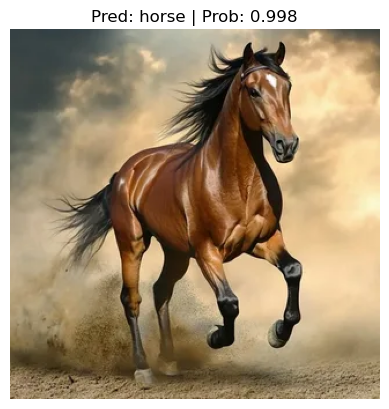

In [38]:
transform_predict(model=loaded_model,image_path=at_path,class_names=class_names)

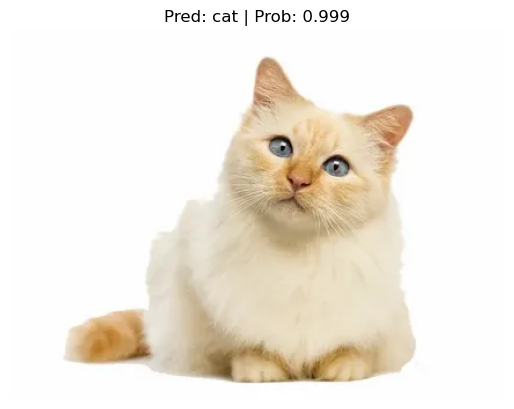

In [35]:
transform_predict(model=loaded_model,image_path=kedi1_path,class_names=class_names)

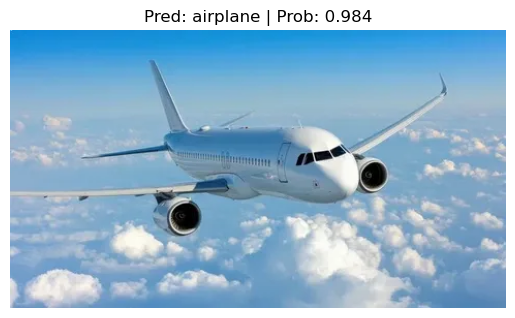

In [36]:
transform_predict(model=loaded_model,image_path=ucak1_path,class_names=class_names)

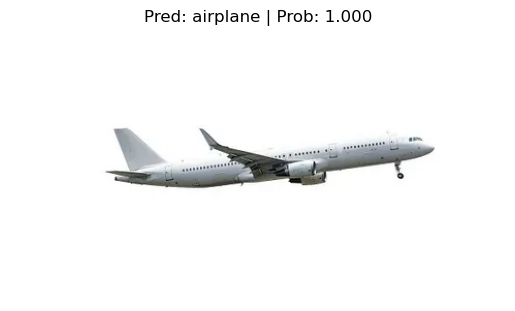

In [37]:
transform_predict(model=loaded_model,image_path=ucak2_path,class_names=class_names)